In [21]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix, classification_report,
    RocCurveDisplay
)

In [22]:
df = pd.read_csv('data/process/loan_data_cleaned.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution:\n{df['loan_status'].value_counts(normalize=True)}")

Dataset shape: (4269, 18)

Target distribution:
loan_status
1    0.62216
0    0.37784
Name: proportion, dtype: float64


In [23]:
# Drop loan_id
df.drop("loan_id", axis=1, inplace=True)

In [24]:
# Features that might cause data leakage (derived from target or future information)
leakage_candidates = [
    'loan_to_income_ratio',   # Derived from loan_amount and income_annum
    'assets_to_loan_ratio',   # Derived from total_assets and loan_amount
    'income_per_dependent',   # Derived from income_annum and no_of_dependents
    'loan_per_term',          # Derived from loan_amount and loan_term
    'total_assets_value'      # Sum of asset columns (can be derived)
]

In [25]:
print("Potential leakage features to remove:")
for feat in leakage_candidates:
    print(f"  - {feat}")

Potential leakage features to remove:
  - loan_to_income_ratio
  - assets_to_loan_ratio
  - income_per_dependent
  - loan_per_term
  - total_assets_value


In [26]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [27]:
print(f"Original features: {X.shape[1]}")

Original features: 16


In [28]:
# Remove leakage features
X_clean = X.drop(columns=leakage_candidates, errors='ignore')
print(f"After removing leakage features: {X_clean.shape[1]}")

After removing leakage features: 11


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.3, random_state=42, stratify=y
)

In [30]:
print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (2988, 11)
Test size: (1281, 11)


In [31]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_split=15,
    min_samples_leaf=8,
    max_features='sqrt',
    bootstrap=True,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [32]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [33]:
# Evaluate baseline
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)
y_train_prob = rf_model.predict_proba(X_train)[:, 1]
y_test_prob = rf_model.predict_proba(X_test)[:, 1]

In [34]:
def evaluate_model(y_true, y_pred, y_prob, dataset_name=""):
    print(f"\n{dataset_name} METRICS:")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1 Score : {f1_score(y_true, y_pred):.4f}")
    print(f"  ROC AUC  : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"  Log Loss : {log_loss(y_true, y_prob):.4f}")

In [35]:
print("\n--- RANDOM FOREST MODEL RESULTS ---")
evaluate_model(y_train, y_train_pred, y_train_prob, "TRAIN")
evaluate_model(y_test, y_test_pred, y_test_prob, "TEST")


--- RANDOM FOREST MODEL RESULTS ---

TRAIN METRICS:
  Accuracy : 0.9639
  Precision: 0.9944
  Recall   : 0.9473
  F1 Score : 0.9702
  ROC AUC  : 0.9990
  Log Loss : 0.1294

TEST METRICS:
  Accuracy : 0.9688
  Precision: 0.9961
  Recall   : 0.9536
  F1 Score : 0.9744
  ROC AUC  : 0.9982
  Log Loss : 0.1314


In [36]:
# Check for overfitting
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
overfit_gap = train_acc - test_acc
print(f"\nOverfitting gap: {overfit_gap:.4f}")
if overfit_gap > 0.02:
    print("Still showing overfitting, will tune further!")
else:
    print("Random Forest looks good!")


Overfitting gap: -0.0049
Random Forest looks good!


In [37]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Cross-validation accuracy scores: [0.95986622 0.95986622 0.95652174 0.96984925 0.95142379]
Mean CV accuracy: 0.9595 (+/- 0.0060)


In [38]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [4, 5, 6, 7],
    'min_samples_split': [10, 15, 20, 25],
    'min_samples_leaf': [5, 8, 10, 12],
    'max_features': ['sqrt', 'log2', 0.5, 0.6],
    'class_weight': ['balanced', 'balanced_subsample']
}

In [39]:
# Use smaller grid for faster tuning (or expand if time allows)
param_grid_small = {
    'n_estimators': [100, 150],
    'max_depth': [5, 6],
    'min_samples_split': [15, 20],
    'min_samples_leaf': [8, 10],
    'max_features': ['sqrt', 0.6],
    'class_weight': ['balanced']
}

In [40]:
print("Performing GridSearchCV (this may take a few minutes)...")
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_small,
    cv=3,  # 3-fold for speed
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

Performing GridSearchCV (this may take a few minutes)...


In [41]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [5, 6], 'max_features': ['sqrt', 0.6], 'min_samples_leaf': [8, 10], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter 

In [42]:
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")


Best parameters: {'class_weight': 'balanced', 'max_depth': 6, 'max_features': 0.6, 'min_samples_leaf': 8, 'min_samples_split': 15, 'n_estimators': 150}
Best CV score: 0.9675


In [43]:
best_model = grid_search.best_estimator_

In [44]:
# Train on full training set
best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.6
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [45]:
# Evaluate
y_train_pred_best = best_model.predict(X_train)
y_test_pred_best = best_model.predict(X_test)
y_train_prob_best = best_model.predict_proba(X_train)[:, 1]
y_test_prob_best = best_model.predict_proba(X_test)[:, 1]

In [46]:
print("\n--- BEST MODEL RESULTS ---")
evaluate_model(y_train, y_train_pred_best, y_train_prob_best, "TRAIN")
evaluate_model(y_test, y_test_pred_best, y_test_prob_best, "TEST")

train_acc_best = accuracy_score(y_train, y_train_pred_best)
test_acc_best = accuracy_score(y_test, y_test_pred_best)
overfit_gap_best = train_acc_best - test_acc_best
print(f"\nOverfitting gap (best model): {overfit_gap_best:.4f}")


--- BEST MODEL RESULTS ---

TRAIN METRICS:
  Accuracy : 0.9732
  Precision: 0.9944
  Recall   : 0.9623
  F1 Score : 0.9781
  ROC AUC  : 0.9993
  Log Loss : 0.0551

TEST METRICS:
  Accuracy : 0.9742
  Precision: 0.9935
  Recall   : 0.9649
  F1 Score : 0.9790
  ROC AUC  : 0.9984
  Log Loss : 0.0573

Overfitting gap (best model): -0.0010


In [47]:
cv_scores_best = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='accuracy')
print(f"\nBest model CV accuracy: {cv_scores_best.mean():.4f} (+/- {cv_scores_best.std():.4f})")


Best model CV accuracy: 0.9645 (+/- 0.0067)


In [48]:
feature_importance = pd.DataFrame({
    "Feature": X_clean.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

In [49]:
print("\nTOP 10 IMPORTANT FEATURES (no leakage):")
print(feature_importance.head(10).to_string(index=False))


TOP 10 IMPORTANT FEATURES (no leakage):
                 Feature  Importance
             cibil_score    0.913204
               loan_term    0.046479
             loan_amount    0.017056
            income_annum    0.007292
     luxury_assets_value    0.004437
 commercial_assets_value    0.003848
residential_assets_value    0.003385
        bank_asset_value    0.002482
        no_of_dependents    0.001110
           self_employed    0.000366


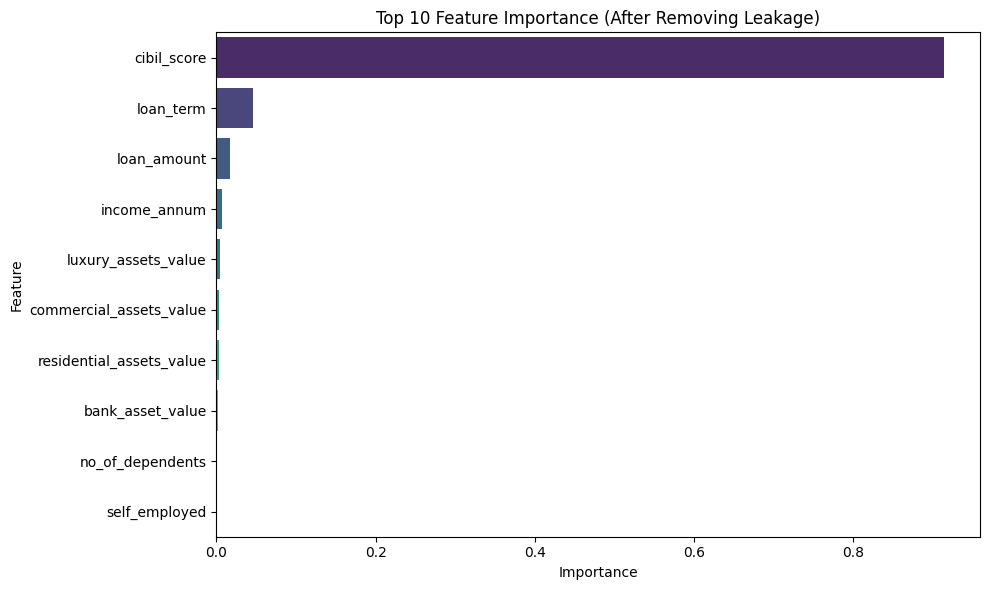

In [50]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x="Importance", y="Feature", palette="viridis")
plt.title("Top 10 Feature Importance (After Removing Leakage)")
plt.tight_layout()
plt.show()

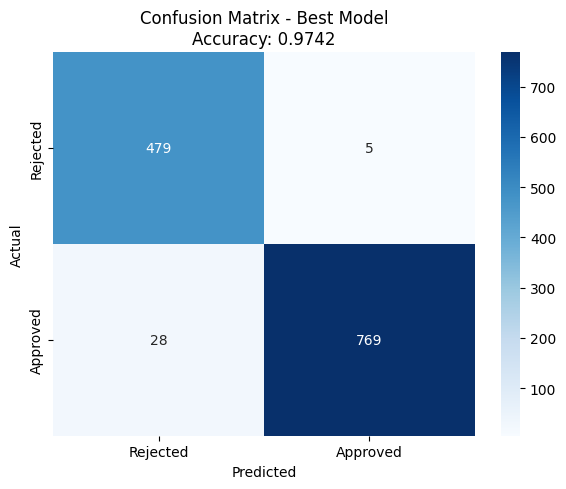

In [51]:
cm = confusion_matrix(y_test, y_test_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title(f"Confusion Matrix - Best Model\nAccuracy: {test_acc_best:.4f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig('confusion_matrix_fixed.png', dpi=150)
plt.show()

In [52]:
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_best))


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       484
           1       0.99      0.96      0.98       797

    accuracy                           0.97      1281
   macro avg       0.97      0.98      0.97      1281
weighted avg       0.98      0.97      0.97      1281



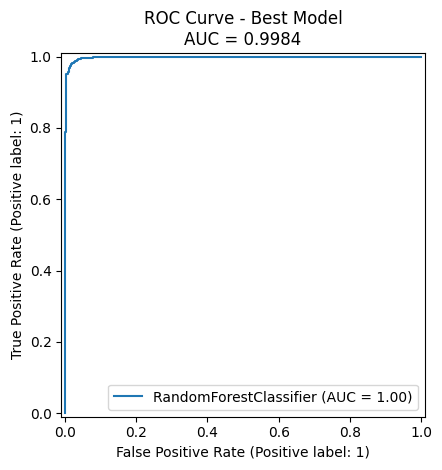

In [55]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"ROC Curve - Best Model\nAUC = {roc_auc_score(y_test, y_test_prob_best):.4f}")
plt.tight_layout()
plt.savefig('roc_curve_fixed.png', dpi=150)
plt.show()

In [56]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'Log Loss', 'Overfitting Gap'],
    'Random Forest (Train)': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        roc_auc_score(y_train, y_train_prob),
        log_loss(y_train, y_train_prob),
        train_acc - test_acc
    ],
    'Random Forest (Test)': [
        test_acc,
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_prob),
        log_loss(y_test, y_test_prob),
        train_acc - test_acc
    ],
    'Best Model (Train)': [
        train_acc_best,
        precision_score(y_train, y_train_pred_best),
        recall_score(y_train, y_train_pred_best),
        f1_score(y_train, y_train_pred_best),
        roc_auc_score(y_train, y_train_prob_best),
        log_loss(y_train, y_train_prob_best),
        train_acc_best - test_acc_best
    ],
    'Best Model (Test)': [
        test_acc_best,
        precision_score(y_test, y_test_pred_best),
        recall_score(y_test, y_test_pred_best),
        f1_score(y_test, y_test_pred_best),
        roc_auc_score(y_test, y_test_prob_best),
        log_loss(y_test, y_test_prob_best),
        train_acc_best - test_acc_best
    ]
})

print(comparison.to_string(index=False))

         Metric  Random Forest (Train)  Random Forest (Test)  Best Model (Train)  Best Model (Test)
       Accuracy               0.963855              0.968774            0.973226           0.974239
      Precision               0.994353              0.996068            0.994441           0.993540
         Recall               0.947283              0.953576            0.962345           0.964868
       F1 Score               0.970248              0.974359            0.978130           0.978994
        ROC AUC               0.998978              0.998242            0.999271           0.998447
       Log Loss               0.129388              0.131367            0.055053           0.057345
Overfitting Gap              -0.004919             -0.004919           -0.001013          -0.001013


In [57]:
joblib.dump(best_model, 'models/random_forest_best_fixed.pkl')
print("Model saved to: models/random_forest_best_fixed.pkl")

Model saved to: models/random_forest_best_fixed.pkl


In [58]:
# Save feature names for inference
feature_names = X_clean.columns.tolist()
joblib.dump(feature_names, 'models/feature_names_fixed.pkl')
print("Feature names saved to: models/feature_names_fixed.pkl")

Feature names saved to: models/feature_names_fixed.pkl


In [60]:
if overfit_gap_best < 0.015:
    print("SUCCESS: Model is well-generalized!")
    print(f"   Training accuracy: {train_acc_best:.4f}")
    print(f"   Testing accuracy : {test_acc_best:.4f}")
    print(f"   Overfitting gap  : {overfit_gap_best:.4f}")
elif overfit_gap_best < 0.03:
    print("ACCEPTABLE: Minor overfitting remains")
    print(f"   Overfitting gap: {overfit_gap_best:.4f}")
else:
    print("WARNING: Still overfitting. Consider:")
    print("   1. Getting more training data")
    print("   2. Further increasing regularization")
    print("   3. Trying a different model (XGBoost, LightGBM)")

print("\n" + "=" * 70)
print("PROGRAM COMPLETED")
print("=" * 70)

SUCCESS: Model is well-generalized!
   Training accuracy: 0.9732
   Testing accuracy : 0.9742
   Overfitting gap  : -0.0010

PROGRAM COMPLETED


#### Save and Load model

In [1]:
import pandas as pd
import numpy as np
import joblib

In [2]:
best_model = joblib.load(
    "models/random_forest_best_fixed.pkl"
)

In [3]:
# Load feature order
feature_columns = joblib.load(
    "models/feature_names_fixed.pkl"
)

In [4]:
print("Features expected by model:")
print(feature_columns)
print(f"\nTotal features: {len(feature_columns)}")

Features expected by model:
['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

Total features: 11


In [5]:
sample_data = {
    "no_of_dependents": 2,
    "education": 1,
    "self_employed": 0,
    "income_annum": 500000,
    "loan_amount": 200000,
    "loan_term": 10,
    "cibil_score": 750,
    "residential_assets_value": 300000,
    "commercial_assets_value": 100000,
    "luxury_assets_value": 50000,
    "bank_asset_value": 200000
}


In [6]:
# Convert to DataFrame
input_df = pd.DataFrame([sample_data])

# Ensure correct column order
input_df = input_df[feature_columns]

# Predict
prediction = best_model.predict(input_df)[0]

# Probability
probability = best_model.predict_proba(input_df)[0][1]

print("Prediction:", prediction)
print("Approval Probability:", probability)

Prediction: 1
Approval Probability: 0.9077608307476605
